In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Segmentação da base de interações entre treino e teste

Como não é um processo interativo, não é necessário separar dados para validação.

Um percentual de interações por usuários será removida da base de interações.

A matriz item-item precisa ser recalculada apenas com os dados de treino.

In [13]:
K = 10

In [14]:
df_similaridade = pd.read_csv(
    '../dados_sinteticos/dados_tratatos/similaridade_item_item.csv',
    index_col=0 
)

df_interacoes_treino = pd.read_parquet('../dados_sinteticos/interacoes_treino.parquet')

df_interacoes_teste = pd.read_parquet('../dados_sinteticos/interacoes_teste.parquet')

In [15]:
df_similaridade.head(5)

,P_0,P_1,P_10,P_11,P_12,P_13,P_14,P_15,P_16,P_17,...,P_90,P_91,P_92,P_93,P_94,P_95,P_96,P_97,P_98,P_99
P_0,1.000000,0.000000,0.044277,0.170036,0.013053,0.000000,0.000000,0.000000,0.051897,0.062071,...,0.000000,0.000000,0.010633,0.0,0.000000,0.000000,0.149624,0.000000,0.038132,0.005890
P_1,0.000000,1.000000,0.000000,0.000000,0.096727,0.000000,0.009647,0.039448,0.000000,0.000000,...,0.000000,0.084355,0.000000,0.0,0.050323,0.019188,0.015019,0.086442,0.101429,0.082315
P_10,0.044277,0.000000,1.000000,0.044079,0.095343,0.000000,0.000000,0.000000,0.000000,0.020372,...,0.027444,0.000000,0.074826,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P_11,0.170036,0.000000,0.044079,1.000000,0.000000,0.000000,0.000000,0.000000,0.050261,0.036552,...,0.066543,0.000000,0.051615,0.0,0.000000,0.000000,0.016058,0.000000,0.000000,0.000000
P_12,0.013053,0.096727,0.095343,0.000000,1.000000,0.024804,0.000000,0.000000,0.000000,0.015453,...,0.000000,0.000000,0.084138,0.0,0.000000,0.085973,0.005064,0.000000,0.076714,0.006874


In [16]:
df_interacoes_treino.head(5)

,id_produto,id_usuario,deslocamento
0,P_19,U_0,5888.346432
1,P_19,U_0,6820.263599
2,P_19,U_0,4457.505640
3,P_27,U_0,4657.755944
4,P_27,U_0,5104.425635


In [17]:
df_interacoes_teste.head(5)

,id_produto,id_usuario,deslocamento
0,P_85,U_0,4534.403437
1,P_21,U_1,2586.277042
2,P_21,U_1,5035.367861
3,P_25,U_10,6844.660804
4,P_25,U_10,6238.370187


In [24]:
df_interacoes_teste

,id_produto,id_usuario,deslocamento
0,P_85,U_0,4534.403437
1,P_21,U_1,2586.277042
2,P_21,U_1,5035.367861
3,P_25,U_10,6844.660804
4,P_25,U_10,6238.370187
...,...,...,...
2060,P_98,U_997,3110.340767
2061,P_88,U_998,2551.928632
2062,P_88,U_998,3261.264085
2063,P_62,U_999,4012.981988


Durante o split, alguns usuários que não tinham mais que uma interação, embora possam receber recomendações, obviamente não fornecem informação para validação, pois não aparecem no teste.

In [18]:
# IDs dos produtos conhecidos pela matriz de similaridade
ids_produtos_arr = df_similaridade.index.values

# Usuários que têm itens no teste (os únicos que serão avaliados)
usuarios_para_recomendar = df_interacoes_teste['id_usuario'].unique()

recomendacoes = {}

# Recomendações por usuário
for id_usuario in usuarios_para_recomendar:

    # Produtos que o usuário adquiriu no treino
    # Estes não serão recomendados
    adquiridos = set(
        df_interacoes_treino[df_interacoes_treino['id_usuario'] == id_usuario]['id_produto']
    )

    # Score acumulado para cada produto candidato
    # produtos similares a vários itens do histórico do usuário acumulam scores mais altos
    # o sistema considera o histórico inteiro
    scores_candidatos = pd.Series(0.0, index=ids_produtos_arr)

    for id_produto in adquiridos:
        if id_produto in df_similaridade.index:
            scores_candidatos += df_similaridade.loc[id_produto]

    # Remove os já comprados no treino
    scores_candidatos = scores_candidatos.drop(index=list(adquiridos), errors='ignore')

    # Top-K produtos mais similares ao histórico do usuário
    top_k = scores_candidatos.nlargest(K).index.tolist()
    recomendacoes[id_usuario] = top_k

print(f"{len(recomendacoes)} usuários receberam recomendações.")

903 usuários receberam recomendações.


In [28]:
suficiente = f'Todas as recomendações foram suficientes para K = {K}.'

for usuario in recomendacoes:
    if len(recomendacoes[usuario])<10:
        suficiente = ''
        print(f'{usuario}: {len(recomendacoes[usuario])}')

print(suficiente)

Todas as recomendações foram suficientes para K = 10.


In [29]:
repetidos = f'Não há recomendações repetidas.'

for usuario in recomendacoes:
    if len(set(recomendacoes[usuario]))<10:
        repetidos = ''
        print(f'{usuario}: {10-len(set(recomendacoes[usuario]))}')

print(repetidos)

Não há recomendações repetidas.


# Precision@K e Recall@K

Verificamos se, dentre os produtos recomendados, o usuário teria adquirido: ou seja, se ele existe no teste.

Como cada usuário tem exatamente 1 item na base de teste, é esperado que o Precision@K * K seja igual ao Recall@K

In [37]:
# Itens relevantes por usuário (produtos distintos no teste)
relevantes_teste = (
    df_interacoes_teste.groupby('id_usuario')['id_produto']
    .apply(set)
    .to_dict()
)

precisoes = []
recalls   = []

for id_usuario, top_k in recomendacoes.items():
    relevantes = relevantes_teste.get(id_usuario, set())

    if not relevantes:
        continue

    acertos = len(set(top_k) & relevantes)

    precisoes.append(acertos / K)
    recalls.append(acertos / len(relevantes))

print(f"Precision@{K}: {np.mean(precisoes):.4f}")
print(f"Recall@{K}:    {np.mean(recalls):.4f}")
print(f"Usuários avaliados: {len(precisoes)}")

Precision@10: 0.0573
Recall@10:    0.5725
Usuários avaliados: 903


# Mean Reciprocal Rank - MMR@K

Para cada usuário, pega a posição do item relevante no Top-K e calcula 1 / posição. Se o item aparece em 1º lugar, vale 1.0. Se aparece em 10º, vale 0.1. Se não aparece, vale 0.

In [39]:
reciprocal_ranks = []

for id_usuario, top_k in recomendacoes.items():
    relevantes = relevantes_teste.get(id_usuario, set())
    if not relevantes:
        continue

    rr = 0.0
    for rank, id_produto in enumerate(top_k, start=1):
        if id_produto in relevantes:
            rr = 1 / rank
            break  # para no primeiro acerto

    reciprocal_ranks.append(rr)

print(f"MRR@{K}: {np.mean(reciprocal_ranks):.4f}")

MRR@10: 0.2362


Em média, o item relevante aparece na posição 1 / 0.2362 ≈ 4.2 do Top-10. Ou seja, o sistema tende a colocar o item correto na 4ª ou 5ª posição da lista.

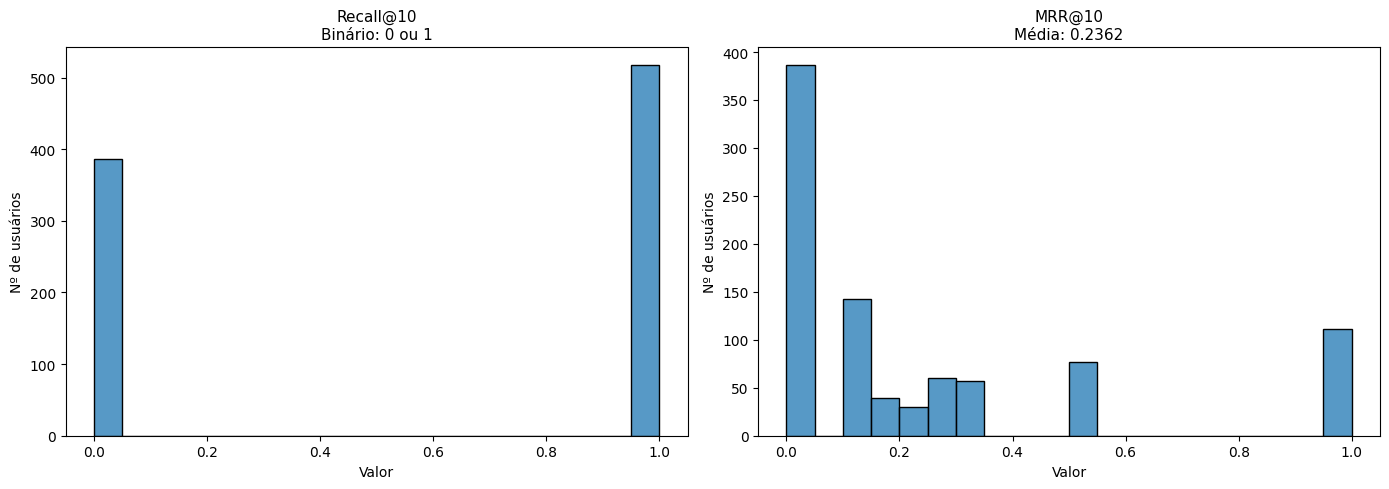

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados = [
    (recalls,          f'Recall@{K}',    'Binário: 0 ou 1'),
    (reciprocal_ranks, f'MRR@{K}',       f'Média: {np.mean(reciprocal_ranks):.4f}')
]

for ax, (valores, titulo, subtitulo) in zip(axes, dados):
    sns.histplot(valores, bins=20, ax=ax)
    ax.set_title(f'{titulo}\n{subtitulo}', fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Nº de usuários')

plt.tight_layout()
plt.show()